# CH 09. 추천 시스템

## 01. 추천 시스템의 개요와 배경
## 추천 시스템의 유형

콘텐츠 기반 필터링 방식

협업 필터링 방식
- 최근접 이웃 협업 필터링
- 잠재 요인 협업 필터링

## 02. 콘텐츠 기반 필터링 추천 시스템

콘텐츠 기반 필터링 방식은 사용자가 특정한 아이템을 매우 선호하는 경우, 그 아이템과 비슷한 콘텐츠를 가진 다른 아이템을 추천하는 방식

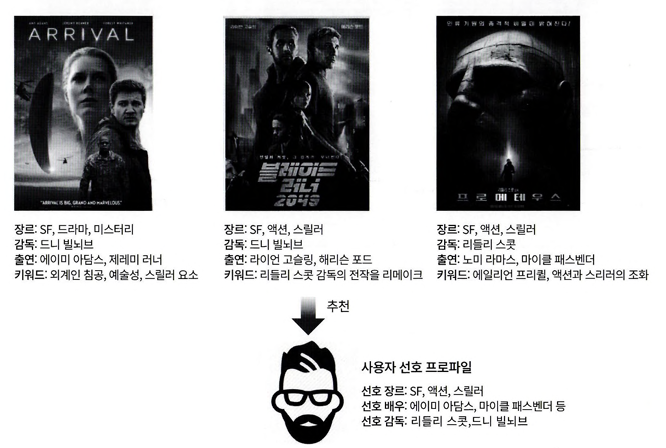

## 03. 최근접 이웃 협업 필터링

사용자가 아이템에 매긴 평점 정보나 상품 구매 이력과 같은 사용자 행동 양식만을 기반으로 추천을 수행


협업 필터링의 주요 목표: 사용자-아이템 평점 매트릭스와 같은 축적된 사용자 행동 데이터를 기반으로 아직 평가하지 않은 아이템을 예측 평가함
아래 그림에서 User1은 Item 4에 대한 평점이 없음. 협업 필터링은 사용자가 평가한 다른 아이템을 기반으로 사용자가 평가하지 않은 아이템의 예측 평가를 도출하는 방식

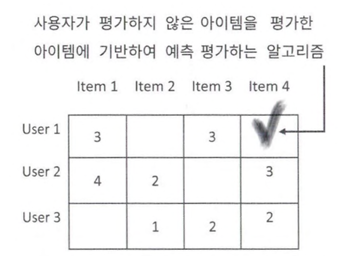

협업 필터링 기반의 추천 시스템 -> 최근접 이웃 방식, 잠재 요인 방식

두 방식 모두 사용자-아이템 평점 행렬 데이터에만 의지해 추천을 수행함. 행은 개별 사용자, 열은 개별 아이템으로 구성.  사용자 아이디 행, 아이템 아이디 열 위치에 해당하는 값이 평점을 나타내는 형태가 되어야 함. 만약 데이터가 다음 그림의 왼쪽과 같이 레코드 레벨 형태인 사용자-아이템 평점 데이터라면 판다스의 pivot_table()과 같은 함수를 이용해 그림의 오른쪽과 같은 형태인 사용자-아이템 평점 행렬로 변경해야 함.

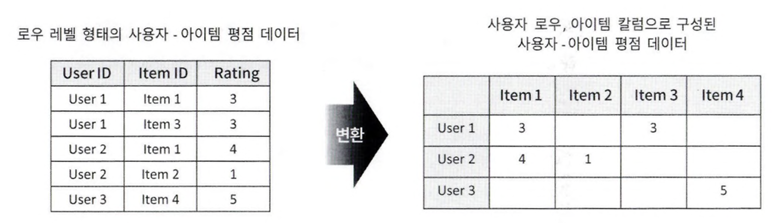

일반적으로 이러한 사용자-아이템 평점 행렬은 많은 아이템을 열로 가지는 다차원 행렬이며, 사용자가 아이템에 대한 평점을 매기는 경우가 많지 않기 때문에 희소 행렬 특성을 가지고 있음.

최근접 이웃 협업 필터링은 메모리 협업 필터링으로도 불림. 일반적으로 사용자 기반/아이템 기반으로 나뉨.

* 사용자 기반: 당신과 비슷한 고객들이 다음 상품도 구매했습니다.
* 아이템 기반: 이 상품을 선택한 다른 고객들은 다음 상품도 구매했습니다.

**사용자 기반 최근접 이웃 방식**은 특정 사용자와 유사한 다른 사용자를 Top-N으로 선정해 이 Top-N 사용자가 좋아하는 아이템을 추천하는 방식. 즉, 특정 사용자와 타 사용자 간의 유사도를 측정한 뒤 가장 유사도가 높은 Top-N 사용자를 추출해 그들이 선호하는 아이템을 추천하는 것임.

<사용자별 영화 평점 정보>

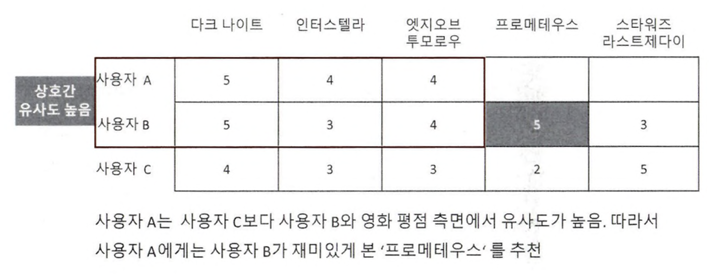

**아이템 기반 최근접 이웃 방식**은 아이템이 가지는 속성과는 상관없이 사용자들이 그 아이템을 좋아하는지/싫어하는지의 평가 척도가 유사한 아이템을 추천하는 기준이 되는 알고리즘임.다음 그림은 아이템 기반 최근접 이웃 방식의 기반 데이터 세트임. 위의 사용자 기반~ 데이터 세트와 행과 열이 서로 반대(행: 개별 아이템, 열: 개별 사용자)

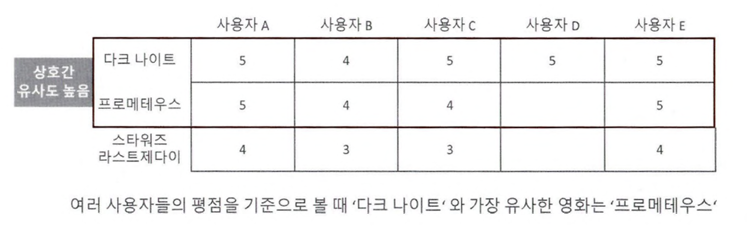

일반적으로 사용자 기반보다는 아이템 기반 협업 필터링이 정확도가 더 높음. 이유는 비슷한 영화를 좋아한다고 해서 사람들의 취향이 비슷하다고 판단하기는 어려운 경우가 많기 때문임. 매우 유명한 영화는 취향과 관계없이 대부분의 사람이 관람하는 경우가 많고, 사용자들이 평점을 매긴 영화의 개수가 많지 않은 경우가 일반적인데 이를 기반으로 다른 사람과의 유사도를 비교하기가 어려움. 따라서 최근접 이웃 협업 필터링은 대부분 아이템 기반의 알고리즘을 적용함.

코사인 유사도는 추천 시스템의 유사도 측정에 가장 많이 적용됨. 추천 시스템에 사용되는 데이터는 피처 벡터화된 텍스트 데이터와 동일하게 다차원 희소 행렬이라는 특징이 있으므로 유사도 측정을 위해 주로 코사인 유사도를 이용함.

## 04. 잠재 요인 협업 필터링

## 잠재 요인 협업 필터링의 이해

잠재 요인 협업 필터링은 사용자-아이템 평점 매트릭스 속에 숨어 있는 잠재 요인을 추출해 추천 예측을 할 수 있게 하는 기법. 대규모 다차원 행렬을 SVD와 같은 차원 감소 기법으로 분해하는 과정에서 잠재 요인을 추출. 이러한 기법을 행렬 분해하고 함.

다차원 희소 행렬인 **사용자-아이템** 행렬 데이터 -> 저차원 밀집 행렬의 **사용자-잠재 요인** 행렬 + **잠재 요인-아이템 행렬** 분해 가능

두 개의 분해된 행렬의 내적을 통해 **새로운 예측 사용자-아이템 평점** 행렬 데이터를 만들어서 사용자가 아직 평점을 부여하지 않는 아이템에 대한 예측 평점을 생성하는 것이 잠재 요인 협력 필터링 알고리즘의 골자.

다음 그림을 통해 더 이해해보자.

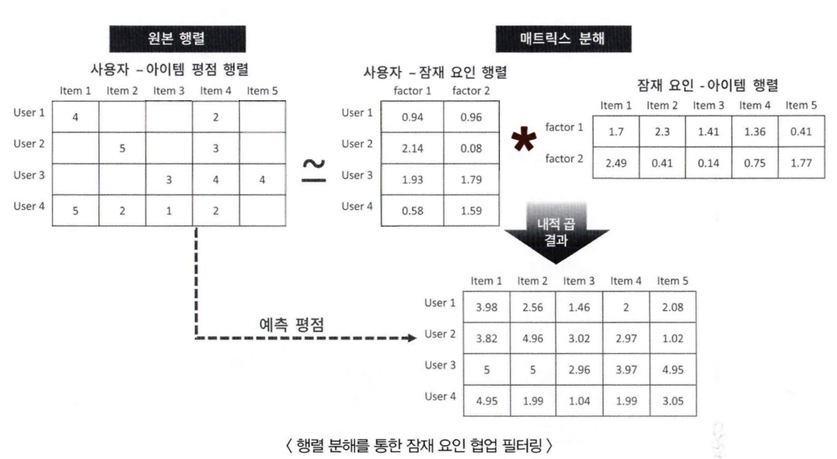


행렬 분해에 의해 추출되는 '잠재 요인'이 정확히 어떤 것인지는 알 수 없지만, 가령 영화 평점 기반의 사용자-아이템 평점 행렬 데이터라면 영화가 가지는 장르별 특성 선호도로 가정할 수 있음. 즉, 사용자-잠재 요인 행렬 -> 사용자의 영화 장르에 대한 선호도/아이템-잠재 요인 행렬 -> 영화의 장르별 특성값 으로 정의.

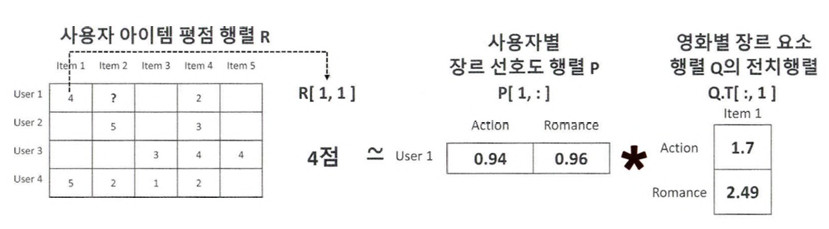

마찬가지 방법으로, User 1이 평점을 매기지 못한 Item 2에 대해 예측 평점을 수행해 보자. 즉, R(1,2)는 행렬 분해된 P 매트릭스의 User 1 벡터와 Q.T 매트릭스의 Item 2 벡터의 내적 결괏값인 2.56으로 예측 가능.

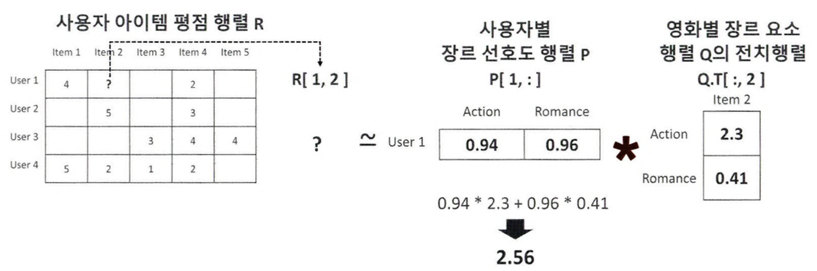

## 행렬 분해의 이해

행렬 분해는 다차원의 매트릭스를 저차원 매트릭스로 분해하는 기법으로서 대표적으로 SVD, NMF 등이 있음. 분해는 우리말로 '인수분해'를 의미함.

M개의 사용자 행과 N개의 아이템 열을 가진 평점 행렬은 M * N 차원으로 구성되며, 행렬 분해를 통해서 사용자-K 차원 잠재 요인 행렬 P(P는 M * K 차원)와 K 차원 잠재 요인-아이템 행렬 Q.T(Q.T는 K * N 차원)로 분해될 수 있음.

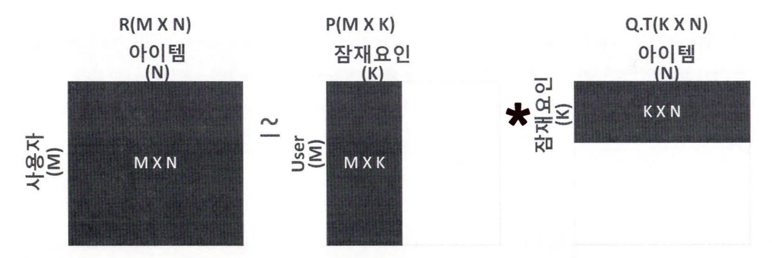

즉, R = P * Q.T이며 각 기호에 대한 설명은 다음과 같다.

* M은 총 사용자 수
* N은 총 아이템 수
* K는 잠재 요인의 차원 수
* R은 M * N 차원의 사용자-아이템 평점 행렬
* P는 사용자와 잠재 요인과의 관계 값을 가지는 M * K 차원의 사용자-잠재 요인 행렬
* Q는 아이템과 잠재 요인과의 관계 값을 가지는 N * K 차원의 아이템-잠재 요인 행렬
* Q.T는 Q 매트릭스의 행과 열 값을 교환한 전치 행렬

예를 들어, 행렬 내에 널(NaN) 값을 많이 가지는 고차원의 희소 행렬인 R 행렬은 다음 그림과 저차원의 밀집 행렬인 P 행렬과 Q 행렬로 분해될 수 있음.

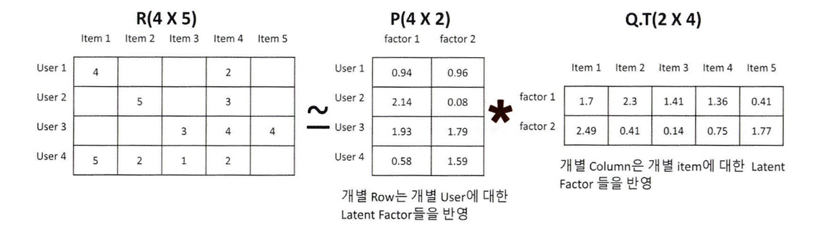

그렇다면 R 행렬을 어떻게 P와 Q 행렬로 분해할까? 행렬 분해는 주로 SVD 방식을 이용함. 하지만 SVD는 널 값이 없는 행렬에만 적용 가능함. R 행렬에는 아직 평점이 되지 않은 많은 널 값이 있기 때문에 P와 Q 행렬을 일반적인 SVD 방식으로는 분해할 수 없다. 이러한 경우에는 확률적 경사 하강법(Stochastic Gradient Descent, SGD)이나 ALS(Alternating Least Squares) 방식을 이용해 SVD를 수행함. 다음에서 경사 하강법을 이용한 행렬 분해에 대해 알아보자.

## 확률적 경사 하강법을 이용한 행렬 분해

확률적 경사 하강법은 5장 회귀에서 배운 경사 하강법의 한 종류이다. 확률적 경사 하강법을 이용한 행렬 분해 방법을 요약하자면, P와 Q 행렬로 계산된 예측 R 행렬 값이 실제 R 행렬 값과 가장 최소의 오류를 가질 수 있도록 반복적인 비용 함수 최적화를 통해 P와 Q를 유추해내는 것이다.

SGD를 이용한 행렬 분해의 전반적인 절차
1. P와 Q를 임의의 값을 가진 행렬로 설정함

2. P와 Q.T 값을 곱해 예측 R 행렬을 계산하고 예측 R 행렬과 실제 R 행렬에 해당하는 오류 값을 계산

3. 이 오류 값을 최소화할 수 있도록 P와 Q 행렬을 적절한 값으로 각각 업데이트함

4. 만족할 만한 오류 값을 가질 때까지 2, 3번 작업을 반복하면서 P와 Q 값을 업데이트해 근사화함


실제 값과 예측값의 오류 최소화와 L2 규제를 고려한 비용 함수식은 다음과 같다.

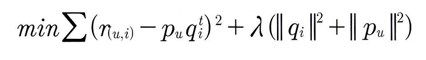

일반적으로 사용자-아이템 평점 행렬의 경우 행렬 분해를 위해서 단순히 예측 오류값의 최소화와 학습시 과적합을 피하기 위해서 규제를 반영한 비용 함수를 적용함.그리고 위의 비용 함수를 최소화하기 위해서 아래와 같이 계산할 수 있음.

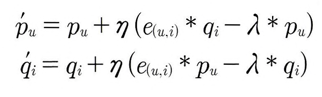

비용 함수식과 업데이트 식의 기호가 의미하는 바는 다음과 같다.

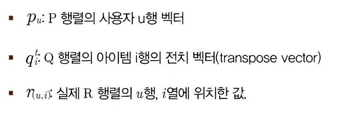

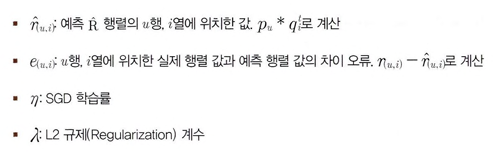


이제 SGD를 이용해 행렬 분해를 수행하는 예제를 파이썬으로 구현해 보자. 분해하려는 원본 행렬 R을 P와 Q로 분해한 뒤에 다시 다시 P와 Q.T의 내적으로 예측 행렬을 만드는 예제이다. 먼저 원본 행렬 R을 미정인 널 값(np.NaN)을 포함해 생성하고 분해 행렬 P와 Q는 정규 분포를 가진 랜덤 값으로 초기화함. 잠재 요인 차원은 3으로 설정하겠음.


In [1]:
import numpy as np

# 원본 행렬 R 생성, 분해 행렬 P와 Q 초기화, 잠재 요인 차원 K는 3으로 생성.
R = np.array([[4,np.nan,np.nan, 2, np.nan ],
              [np.nan, 5, np.nan, 3, 1],
              [np.nan, np.nan, 3, 4, 4],
              [5, 2, 1, 2, np.nan]])

num_users, num_items = R.shape
K=3

# P와 Q 행렬의 크기를 지정하고 정규 분포를 가진 임의의 값으로 입력
np.random.seed(1)
P = np.random.normal(scale=1./K, size=(num_users, K))
Q = np.random.normal(scale=1./K, size=(num_items, K))

다음으로 실제 R 행렬과 예측 행렬의 오차를 구하는 get_rmse() 함수를 만들어 보자. get_rmse() 함수는 실제 R 행렬의 널이 아닌 행렬 값의 위치 인덱스를 추출해 이 인덱스에 있는 실제 R 행렬 값과 분해된 P, Q를 이용해 다시 조합된 예측 행렬 값의 RMSE 값을 반환함.

In [2]:
from sklearn.metrics import mean_squared_error

def get_rmse(R,P,Q,non_zeros):
  error=0
  # 두 개의 분해된 행렬 P와 Q.T의 내적으로 예측 R 행렬 생성
  full_pred_matrix = np.dot(P,Q.T)

  # 실제 R 행렬에서 널이 아닌 값의 위치 인덱스 추출해 실제 R 행렬과 예측 행렬의 RMSE 추출
  x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
  y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
  R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]
  full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]
  mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
  rmse = np.sqrt(mse)

  return rmse

이제 SGD 기반으로 행렬 분해를 수행하자. 먼저 R에서 널 값을 제외한 데이터의 행렬 인덱스를 추출한다. steps는 SGD를 반복해서 업데이트할 횟수를 의미하며, learning_rate는 SGD의 학습률, r_lambda는 L2 Regularization 계수이다. steps=1000번 동안 반복하면서 새로운 p,q 값으로 업데이트한다. 그리고 get_rmse() 함수를 통해 50회 반복할 때마다 오류 값을 출력한다.

In [3]:
# R > 0인 행 위치, 열 위치, 값을 non_zeros 리스트에 저장.
non_zeros = [(i,j,R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j]>0]

steps = 1000
learning_rate = 0.01
r_lambda = 0.01

# SGD 기법으로 P와 Q 매트릭스를 계속 업데이트.
for step in range(steps):
  for i, j, r in non_zeros:
    # 실제 값과 예측 값의 차이인 오류 값 구함
    eij = r - np.dot(P[i,:],Q[j,:].T)
    # Regularization을 반영한 SGD 업데이트 공식 적용
    P[i,:] = P[i,:] + learning_rate*(eij*Q[j,:]-r_lambda*P[i,:])
    Q[j,:] = Q[j,:] + learning_rate*(eij*P[i,:]-r_lambda*Q[j,:])

    rmse = get_rmse(R,P,Q,non_zeros)
    if (step%50) ==0:
      print("### iteration step : ", step, " rmse : ", rmse)

### iteration step :  0  rmse :  3.261355059488935
### iteration step :  0  rmse :  3.26040057174686
### iteration step :  0  rmse :  3.253984404542389
### iteration step :  0  rmse :  3.2521583839863624
### iteration step :  0  rmse :  3.252335303789125
### iteration step :  0  rmse :  3.251072196430487
### iteration step :  0  rmse :  3.2492449982564864
### iteration step :  0  rmse :  3.247416477570409
### iteration step :  0  rmse :  3.241926055455223
### iteration step :  0  rmse :  3.2400454107613084
### iteration step :  0  rmse :  3.240166740749792
### iteration step :  0  rmse :  3.2388050277987723
### iteration step :  50  rmse :  0.5003190892212748
### iteration step :  50  rmse :  0.5001616291326989
### iteration step :  50  rmse :  0.49899601202578087
### iteration step :  50  rmse :  0.4988483450145831
### iteration step :  50  rmse :  0.49895189256631756
### iteration step :  50  rmse :  0.49833236830090993
### iteration step :  50  rmse :  0.4984148489378701
### iterati

이제 분해된 P와 Q 함수를 P*Q.T로 예측 행렬을 만들어서 출력해 보자.

In [4]:
pred_matrix = np.dot(P,Q.T)
print('예측 행렬 : \n', np.round(pred_matrix,3))

예측 행렬 : 
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]


원본 행렬과 비교해 널이 아닌 값은 큰 차이가 나지 않으며, 널인 값은 새로운 예측값으로 채워졌다.